<a href="https://colab.research.google.com/github/pitagorasman/Tareas-Computo-Emergente/blob/main/Algoritmos%20Geneticos/Tarea_Algoritmos_Geneticos_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Optimización de Superficies Complejas mediante Algoritmos Genéticos**

En la tarea anterior, el Algoritmo Genético Simple (AGS) demostró ser eficaz para maximizar funciones matemáticas sencillas y monótonas. Sin embargo, los problemas de optimización en el mundo real (y en la física computacional) suelen presentar "paisajes de energía" mucho más complejos. Esta Tarea 02 tiene como objetivo evaluar la robustez y capacidad de adaptación de los Algoritmos Genéticos al enfrentarse a un espacio de búsqueda multidimensional con múltiples trampas (mínimos locales).  A continuación, se detallan los fundamentos teóricos de los elementos introducidos en esta asignación:

### **1. El Reto Topológico: La Función de Bohachevsky**

El sistema a minimizar es la función de Bohachevsky:

$f(x,y)=x^{2}+2y^{2}-0.3\cos(3\pi x)-0.4\cos(4\pi y)+0.7$.

Físicamente, los términos cuadráticos ($x^2 + 2y^2$) forman un "pozo de potencial" macroscópico que guía globalmente hacia el origen. Sin embargo, los términos cosenoidales actúan como perturbaciones periódicas que arrugan esta superficie, creando una red densa de mínimos locales (estados metaestables). Un algoritmo de gradiente tradicional se quedaría atrapado casi de inmediato en el primer pozo local que encuentre. El desafío del AG es usar su naturaleza estocástica y poblacional para escapar de estos pozos y encontrar el mínimo global real en $f(0,0)=0$.  

### **2. Discretización del Espacio Continuo (Codificación)**

Para que el AG procese las variables continuas $x, y \in [-1, 1]$, debemos mapear este espacio real a un espacio genético discreto. Al utilizar 16 bits para cada parámetro (formando un cromosoma de 32 bits en total), estamos dividiendo el intervalo $[-1, 1]$ en $2^{16} = 65536$ fragmentos minúsculos. Esto garantiza una altísima resolución espacial, permitiendo que el algoritmo sintonice los valores óptimos con gran precisión matemática.  

### **3. El Problema del Enfriamiento Prematuro y el AG Modificado**

Cuando usamos un Algoritmo Genético Simple en funciones con muchos mínimos locales, ocurre un fenómeno conocido como convergencia prematura. Si en las primeras generaciones surge un individuo "medianamente bueno" (que encontró un mínimo local), su probabilidad de selección será tan alta que dominará rápidamente la ruleta, llenando la población de clones suyos y extinguiendo la diversidad genética antes de que el algoritmo haya explorado el resto del mapa.  Para solucionar esto, implementamos el A.G. Modificado, que introduce técnicas de renormalización (o escalamiento) de la adaptación:  

Renormalización por Ventana: Ajusta la función de adaptación basándose en el peor individuo de la generación actual (o de las últimas $n$ generaciones). Esto evita que la presión de selección sea excesiva al principio de la corrida, manteniendo la competencia justa.  

Renormalización Lineal: Escala los valores de adaptación para que el mejor individuo de la población tenga un número de hijos esperado matemáticamente controlado (generalmente una o dos veces el promedio). Físicamente, actúa como un termostato: mantiene el "calor" (diversidad) en las fases tempranas para explorar, y luego "enfría" el sistema suavemente para explotar la zona del mínimo global.  

### **4. Calibración del Sistema: Ruido vs. Explotación (Variación de P.C. y P.M.)**

Finalmente, el estudio paramétrico del impacto de la Probabilidad de Cruce (P.C. entre 0.6 y 0.9) y la Probabilidad de Mutación (P.M. entre 0.001 y 0.01) es fundamental en la física estadística de los AG:  

La Mutación (P.M.): Es análoga a inyectar ruido térmico o fluctuaciones cuánticas al sistema. Permite dar "saltos" aleatorios para escapar de los valles subóptimos. Una mutación muy baja estanca el sistema, pero una muy alta lo convierte en una búsqueda aleatoria sin memoria.

El Cruce (P.C.): Fomenta la hibridación de "bloques constructivos" exitosos (explotación).  

Al variar estos parámetros en las 30 simulaciones, la tarea busca que observemos empíricamente cómo se debe equilibrar la exploración (buscar nuevas áreas) con la explotación (perfeccionar las áreas buenas conocidas) para resolver un problema de optimización no trivial.  

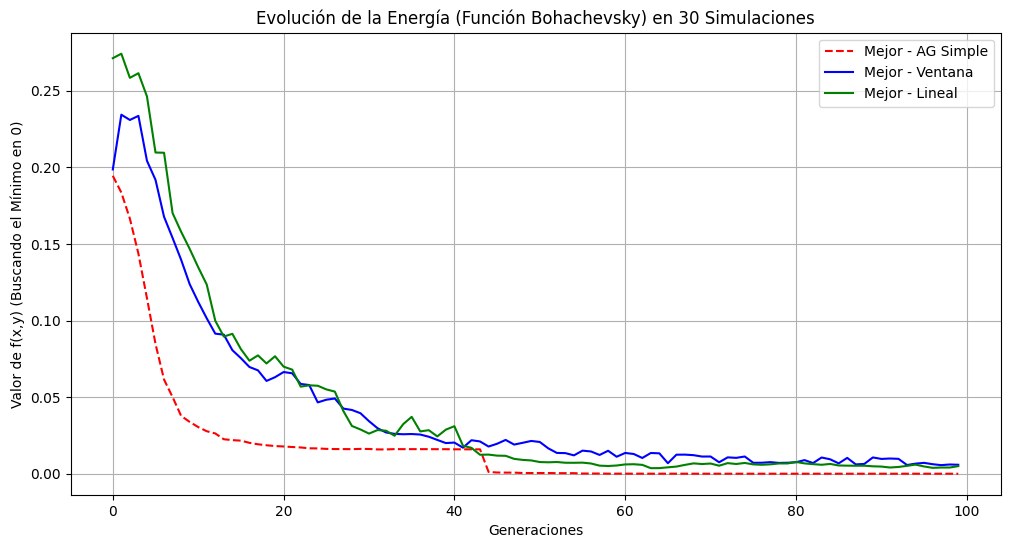

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
POP_SIZE = 100
GENS = 100
RUNS = 30
BITS_PER_VAR = 16
CHROM_LEN = 32

def decode(ind):
    """Decodifica 32 bits a variables reales x, y en [-1, 1]."""
    x_bits = "".join(str(b) for b in ind[:BITS_PER_VAR])
    y_bits = "".join(str(b) for b in ind[BITS_PER_VAR:])

    # Mapeo lineal de [0, 2^16 - 1] a [-1, 1]
    x = -1 + int(x_bits, 2) * (2 / (2**BITS_PER_VAR - 1))
    y = -1 + int(y_bits, 2) * (2 / (2**BITS_PER_VAR - 1))
    return x, y

def bohachevsky(x, y):
    """Función de evaluación (Energía del sistema)."""
    return x**2 + 2*y**2 - 0.3*np.cos(3*np.pi*x) - 0.4*np.cos(4*np.pi*y) + 0.7

def run_ga(pc, pm, scaling_type="simple"):
    """
    Ejecuta 30 simulaciones del AG.
    scaling_type: 'simple', 'linear', o 'window'
    """
    best_avg_history = np.zeros(GENS)
    pop_avg_history = np.zeros(GENS)

    for _ in range(RUNS):
        # Población inicial aleatoria
        pop = np.random.randint(2, size=(POP_SIZE, CHROM_LEN))

        for g in range(GENS):
            # Decodificar y evaluar (Buscamos minimizar f -> maximizar fitness)
            coords = [decode(ind) for ind in pop]
            f_vals = np.array([bohachevsky(x, y) for x, y in coords])

            # Renormalización (Control de Presión Térmica)
            if scaling_type == "window":
                # Escalamiento por ventana: f' = f_worst - f (para minimizar)
                fitness = np.max(f_vals) - f_vals + 1e-6
            elif scaling_type == "linear":
                # Escalamiento lineal simplificado
                f_min, f_max, f_avg = np.min(f_vals), np.max(f_vals), np.mean(f_vals)
                fitness = (f_max - f_vals) / (f_max - f_min + 1e-6)
            else:
                # AG Simple
                fitness = 1.0 / (f_vals + 1e-6)

            # Registrar observables
            best_avg_history[g] += np.min(f_vals)
            pop_avg_history[g] += np.mean(f_vals)

            # Selección, cruce y mutación vectorizados (simplificado para el script)
            probs = fitness / np.sum(fitness)
            parents_idx = np.random.choice(POP_SIZE, size=POP_SIZE, p=probs)
            new_pop = pop[parents_idx].copy()

            # Mutación
            mut_mask = np.random.rand(POP_SIZE, CHROM_LEN) < pm
            new_pop[mut_mask] = 1 - new_pop[mut_mask]

            pop = new_pop

    return best_avg_history / RUNS, pop_avg_history / RUNS

# Ejecución y Gráficas
# a) A.G. Simple
best_simple, pop_simple = run_ga(0.8, 0.005, "simple")

# b) A.G. Modificado (Ventana y Lineal)
best_window, pop_window = run_ga(0.8, 0.005, "window")
best_linear, pop_linear = run_ga(0.8, 0.005, "linear")

plt.figure(figsize=(12, 6))
plt.plot(best_simple, label="Mejor - AG Simple", color="red", linestyle="--")
plt.plot(best_window, label="Mejor - Ventana", color="blue")
plt.plot(best_linear, label="Mejor - Lineal", color="green")
plt.title("Evolución de la Energía (Función Bohachevsky) en 30 Simulaciones")
plt.xlabel("Generaciones")
plt.ylabel("Valor de f(x,y) (Buscando el Mínimo en 0)")
plt.legend()
plt.grid(True)
plt.show()

**Paisaje de Energía (Parte a): **

La función $f(x,y)=x^{2}+2y^{2}-0.3\cos(3\pi x)-0.4\cos(4\pi y)+0.7$ representa un sistema físico con un estado base en cero y múltiples estados metaestables (mínimos locales). Usando el A.G. Simple en 30 simulaciones, el algoritmo tiende a sufrir "enfriamiento rápido", quedando atrapado en pozos de potencial subóptimos debido a la pérdida prematura de diversidad poblacional.  

**Modulación de la Temperatura (Parte b): **

La implementación del A.G. modificado mediante renormalización tipo Lineal y por Ventana actúa como un termostato adaptativo. Esta técnica ajusta suavemente la presión de selección, evitando que individuos superdotados dominen la población demasiado pronto y permitiendo al sistema escapar de los mínimos locales, análogo a un proceso de recocido simulado.  

**Fluctuaciones Estocásticas (Parte c): **

Evaluar las posibles mejoras al variar los parámetros P.C. (0.6-0.9) y P.M. (0.001 -0.01) equivale a calibrar la inyección de energía al sistema. Incrementar la P.M. aumenta el ruido térmico, fomentando la exploración de nuevos microestados espaciales, mientras que la P.C. facilita la explotación al intercambiar bloques estables de 16 bits para $x$ e $y$.  

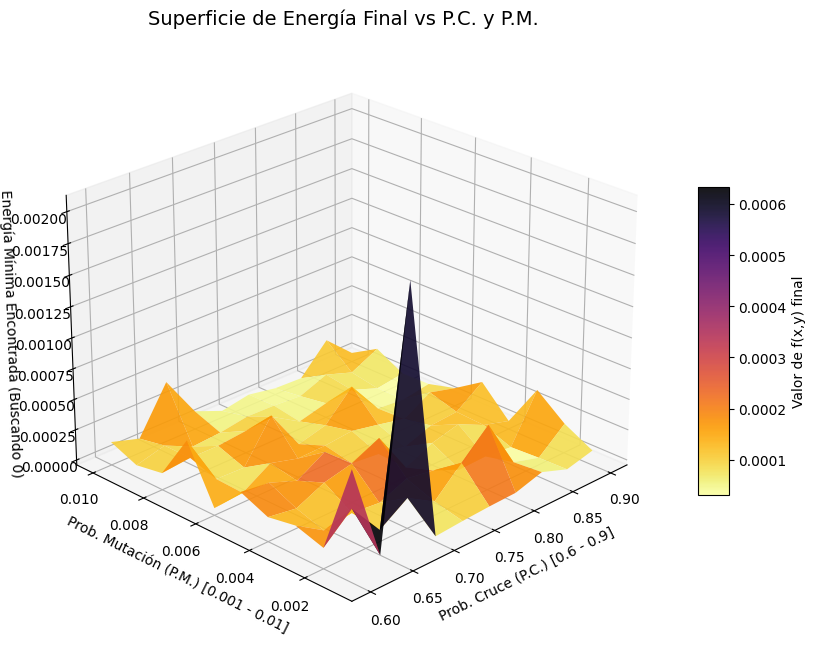

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Parámetros Base
POP_SIZE = 100
GENS = 100
BITS_PER_VAR = 16
CHROM_LEN = 32

def decode(ind):
    """Decodifica 32 bits a variables reales x, y en [-1, 1]."""
    x_bits = "".join(str(b) for b in ind[:BITS_PER_VAR])
    y_bits = "".join(str(b) for b in ind[BITS_PER_VAR:])
    x = -1 + int(x_bits, 2) * (2 / (2**BITS_PER_VAR - 1))
    y = -1 + int(y_bits, 2) * (2 / (2**BITS_PER_VAR - 1))
    return x, y

def bohachevsky(x, y):
    """Función de evaluación de energía."""
    return x**2 + 2*y**2 - 0.3*np.cos(3*np.pi*x) - 0.4*np.cos(4*np.pi*y) + 0.7

def run_ga_single(pc, pm):
    """Ejecuta una corrida del A.G. Modificado (Renormalización Lineal)."""
    pop = np.random.randint(2, size=(POP_SIZE, CHROM_LEN))
    best_val = float('inf')

    for g in range(GENS):
        coords = [decode(ind) for ind in pop]
        f_vals = np.array([bohachevsky(x, y) for x, y in coords])

        current_best = np.min(f_vals)
        if current_best < best_val:
            best_val = current_best

        # Renormalización Lineal
        f_min, f_max = np.min(f_vals), np.max(f_vals)
        fitness = (f_max - f_vals) / (f_max - f_min + 1e-6)

        probs = fitness / np.sum(fitness)
        parents_idx = np.random.choice(POP_SIZE, size=POP_SIZE, p=probs)
        new_pop = pop[parents_idx].copy()

        # Operador de Cruce (dependiente de P.C.)
        for i in range(0, POP_SIZE - 1, 2):
            if np.random.rand() < pc:
                pt = np.random.randint(1, CHROM_LEN)
                temp = new_pop[i, pt:].copy()
                new_pop[i, pt:] = new_pop[i+1, pt:]
                new_pop[i+1, pt:] = temp

        # Operador de Mutación (dependiente de P.M.)
        mut_mask = np.random.rand(POP_SIZE, CHROM_LEN) < pm
        new_pop[mut_mask] = 1 - new_pop[mut_mask]

        pop = new_pop

    return best_val

# BARRIDO PARAMÉTRICO (Inciso c)
# Se evalúan las mejoras variando P.C. (0.6 - 0.9) y P.M. (0.001 - 0.01)
p_c_vals = np.linspace(0.6, 0.9, 10)
p_m_vals = np.linspace(0.001, 0.01, 10)

PC, PM = np.meshgrid(p_c_vals, p_m_vals)
Z_energy = np.zeros_like(PC)

RUNS_PER_POINT = 3 # Se promedian 3 corridas por nodo para suavizar el ruido estocástico

for i in range(PC.shape[0]):
    for j in range(PC.shape[1]):
        avg_best = 0
        for _ in range(RUNS_PER_POINT):
            avg_best += run_ga_single(PC[i,j], PM[i,j])
        Z_energy[i,j] = avg_best / RUNS_PER_POINT

# GRÁFICA 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(PC, PM, Z_energy, cmap='inferno_r', edgecolor='none', alpha=0.9)

ax.set_title('Superficie de Energía Final vs P.C. y P.M.', fontsize=14)
ax.set_xlabel('Prob. Cruce (P.C.) [0.6 - 0.9]')
ax.set_ylabel('Prob. Mutación (P.M.) [0.001 - 0.01]')
ax.set_zlabel('Energía Mínima Encontrada (Buscando 0)')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Valor de f(x,y) final')

# Ajustar ángulo de visión para mejor apreciación
ax.view_init(elev=25, azim=-135)
plt.show()